In [99]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [100]:
def expo(x, a):
    return np.exp(-a/x)

In [101]:
x = np.linspace(0,5, 100)[1:]
# y = expo(np.clip(x, 1e-10, None))


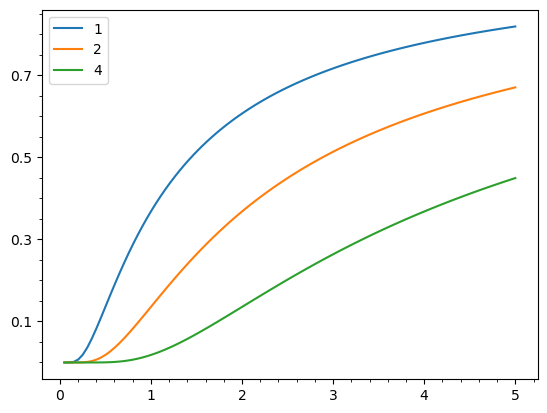

In [102]:
for a,lbl in zip([1,2,4], [1,2,4]):
    plt.plot(x, expo(x, a), label= lbl)
    plt.minorticks_on()
    plt.gca().yaxis.set_major_locator(ticker.FixedLocator([0.1, 0.3, 0.5, 0.7, 0.9]))
    plt.legend()

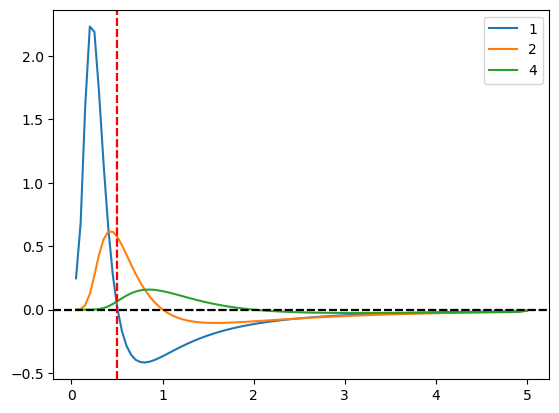

In [103]:
for a,lbl in zip([1,2,4], [1,2,4]):
    g2 = np.gradient(np.gradient(expo(x, a), x), x)
    plt.plot(x, g2, label=lbl)
    plt.axhline(0,c='black', ls='--')
    plt.axvline(0.5,c='red', ls='--')
    plt.legend()
    

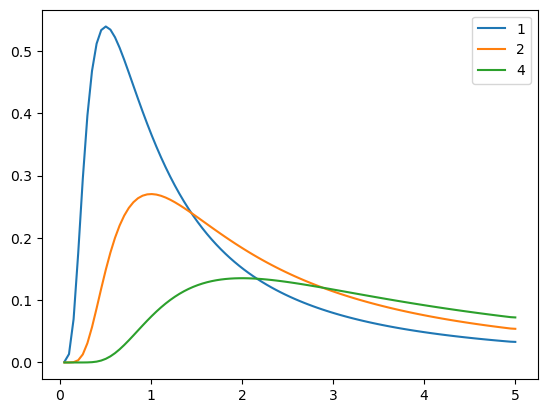

In [104]:
for a,lbl in zip([1,2,4], [1,2,4]):
    g1 = np.gradient(expo(x, a), x)
    plt.plot(x, g1, label=lbl)
    plt.legend()

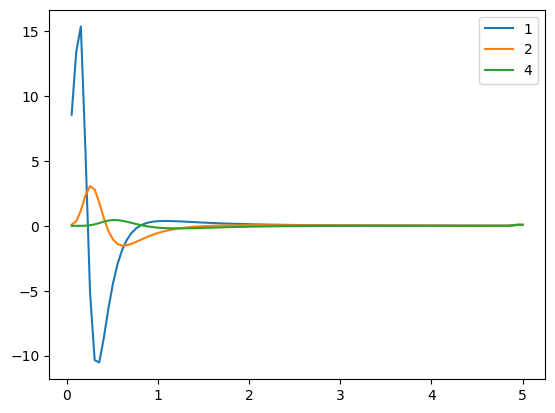

In [105]:
for a,lbl in zip([1,2,4], [1,2,4]):
    g3 = np.gradient(np.gradient(np.gradient(expo(x, a), x), x), x)
    plt.plot(x, g3, label=lbl)
    plt.legend()

In [106]:
def v1(m1,m2,alpha,beta):
    return -(alpha/m1)-(beta/(m1+m2))-np.log(m1)

In [107]:
def R_grid(m2, alpha, beta, hi= 30, n=20000):
    grid = np.linspace(0, hi, n)[1:]
    return grid[np.argmax(v1(grid, m2, alpha, beta))]

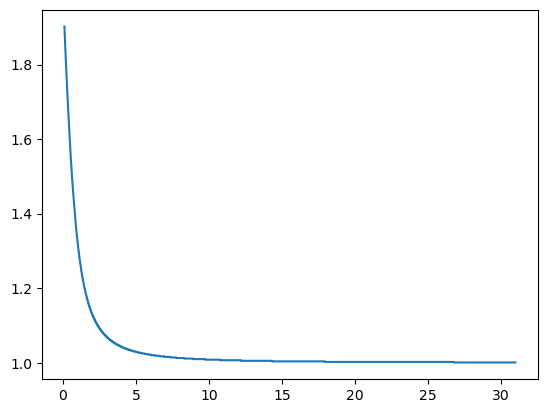

In [108]:
m2_vals = np.linspace(0.1, 31, 5000)
r_vals = [R_grid(m2, alpha=1.0, beta=1.0) for m2 in m2_vals]

plt.plot(m2_vals, r_vals)

In [109]:
from scipy.optimize import brentq

In [110]:
def psi(m1, m2, alpha, beta):
    return alpha + ((beta*(m1**2))/(m1+m2)**2)-m1

In [111]:
def R_root(m2, alpha, beta):
    return brentq(psi, 1e-10, 1e9, args=(m2, alpha, beta))

In [122]:
r_roots = [R_root(m2, 1, 10) for m2 in m2_vals]

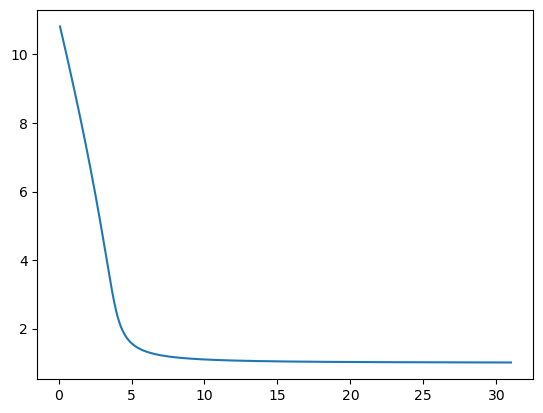

In [123]:
plt.plot(m2_vals, r_roots)

In [124]:
def iterate(m0, alpha, beta, n=60):
    traj = [m0]
    for _ in range(n):
        traj.append(R_root(traj[-1], alpha, beta))
    return np.array(traj)

In [125]:
print(iterate(5, 1, 1,  n=30)[-6:])   # expect all ≈ 1.25
print(iterate(5, 1, 10, n=30)[-6:])   # expect alternating ≈ 1.13, 8.87

[1.25 1.25 1.25 1.25 1.25 1.25]
[1.12701665 8.87298335 1.12701665 8.87298335 1.12701665 8.87298335]
